In [1]:
#importing libabries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [2]:
df=pd.read_excel('Regional_sales.xlsx',sheet_name=None)


In [3]:
#assign dataframe to each sheet
df_sales=df['Sales Orders']
df_customers=df['Customers']
df_regions=df['Regions']
df_States=df['State Regions']
df_product=df['Products']
df_budget=df['2017 Budgets']

print("df_sales shape",(df_sales.shape))
print("df_customers shape",(df_customers.shape))
print("df_regions shape",(df_regions.shape))
print("df_state shape",(df_States.shape))
print("df_product shape",(df_product.shape))
print("df_budget shape",(df_budget.shape))

df_sales shape (64104, 12)
df_customers shape (175, 2)
df_regions shape (994, 15)
df_state shape (49, 3)
df_product shape (30, 2)
df_budget shape (30, 2)


In [4]:
df_sales.head(4)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852


In [5]:
df_customers.head(5)

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [6]:
df_regions.head(5)

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [7]:
new_header=df_States.iloc[0]
df_States.columns=new_header
df_States=df_States[1:].reset_index(drop=True)

df_States.head(5)


,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [8]:
df_product.head(5)

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [9]:
df_budget.head(5)

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [10]:
df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [11]:
df_customers.isnull().sum()

Customer Index    0
Customer Names    0
dtype: int64

In [12]:
df_regions.isnull().sum()

id               0
name             0
county           0
state_code       0
state            0
type             0
latitude         0
longitude        0
area_code        0
population       0
households       0
median_income    0
land_area        0
water_area       0
time_zone        0
dtype: int64

In [13]:
df_States.isnull().sum()

0
State Code    0
State         0
Region        0
dtype: int64

In [14]:
df_product.isnull().sum()

Index           0
Product Name    0
dtype: int64

In [15]:
df_budget.isnull().sum()

Product Name    0
2017 Budgets    0
dtype: int64

#### **data cleaning and wrangling**

In [16]:
#merging with customers
df=  df_sales.merge(
    df_customers,
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
)
df.head(5)


,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [17]:
#merge with product
df=df.merge(
    df_product,
    how='left',
    left_on='Product Description Index',
    right_on='Index',
    indicator=True
)
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name,_merge
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27,both
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20,both
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26,both
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7,both
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8,both


In [18]:
#merging with  regions
df=df.merge(
    df_regions,
    how='left',
    left_on='Delivery Region Index',
    right_on='id'
)
df.head(5)



,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [19]:
#merging with state regions
df=df.merge(
    df_States[["State Code","Region" ]],
    how='left',
    left_on='state_code',
    right_on='State Code'
)
df.head(5)



,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast


In [20]:
#merge with budgets
df=df.merge(
    df_budget,
    how='left',
    on='Product Name'
)
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329


In [21]:
#index
#id
#state

#clean up redundant columns
cols_drops=['Index','id','State Code','customer index','_merge']
df=df.drop(columns=cols_drops,errors='ignore' )
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [22]:
#convert all columns to lowercase for consistency and easily access
df.columns=df.columns.str.lower()
df.columns.values


array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer index',
       'customer names', 'product name', 'name', 'county', 'state_code',
       'state', 'type', 'latitude', 'longitude', 'area_code',
       'population', 'households', 'median_income', 'land_area',
       'water_area', 'time_zone', 'region', '2017 budgets'], dtype=object)

In [23]:
#keep the important columns and the delete that we don't need
cols_to_keep=[
    'ordernumber',
    'orderdate',
    'channel',
    'product name',
    'order quantity',
    'unit price',
    'line total',
    'total unit cost',
   'customer names',
    'county',
    'state_code',
    'state',
    'latitude',
    'longitude',
    'region',
    '2017 budgets'
    
]

In [24]:
df=df[cols_to_keep]

In [25]:
df.head(5)

,ordernumber,orderdate,channel,product name,order quantity,unit price,line total,total unit cost,customer names,county,state_code,state,latitude,longitude,region,2017 budgets
0,SO - 000225,2014-01-01,Wholesale,Product 27,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Chatham County,GA,Georgia,32.08354,-81.09983,South,964940.231
1,SO - 0003378,2014-01-01,Distributor,Product 20,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Johnson County,IN,Indiana,39.61366,-86.10665,Midwest,2067108.120
2,SO - 0005126,2014-01-01,Wholesale,Product 26,6,978.2,5869.2,684.740,Amerisourc Corp,Alameda County,CA,California,37.66243,-121.87468,West,5685138.270
3,SO - 0005614,2014-01-01,Export,Product 7,7,2338.3,16368.1,1028.852,Colgate-Pa Group,Monroe County,IN,Indiana,39.16533,-86.52639,Midwest,889737.555
4,SO - 0005781,2014-01-01,Wholesale,Product 8,8,2291.4,18331.2,1260.270,Deseret Group,Hartford County,CT,Connecticut,41.77524,-72.52443,Northeast,1085037.329


In [26]:
#rename the column

df=df.rename(columns={
    'ordernumber':'order_number',
    'orderdate':'order_date',
    'product name':'product_name',
    'order quantity':'order_quantity',
    'unit price':'unit_price',
    'line total':'revenue',
    'total unit cost':'total_unit',
    'customer names':'customer_name',
    '2017 budgets':'budget'
})
df.head(2)

,order_number,order_date,channel,product_name,order_quantity,unit_price,revenue,total_unit,customer_name,county,state_code,state,latitude,longitude,region,budget
0,SO - 000225,2014-01-01,Wholesale,Product 27,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Chatham County,GA,Georgia,32.08354,-81.09983,South,964940.231
1,SO - 0003378,2014-01-01,Distributor,Product 20,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Johnson County,IN,Indiana,39.61366,-86.10665,Midwest,2067108.120


In [27]:
#blank out budget non the 2017  budget
df.loc[df['order_date'].dt.year !=  2017,'budget']=pd.NA

#line total revenue
df[['order_date','product_name','revenue','budget']].head(5)

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN


In [28]:
#line total is revenue
df.to_csv('final.csv')

#### Feature Engineering

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_number    64104 non-null  object        
 1   order_date      64104 non-null  datetime64[ns]
 2   channel         64104 non-null  object        
 3   product_name    64104 non-null  object        
 4   order_quantity  64104 non-null  int64         
 5   unit_price      64104 non-null  float64       
 6   revenue         64104 non-null  float64       
 7   total_unit      64104 non-null  float64       
 8   customer_name   64104 non-null  object        
 9   county          64104 non-null  object        
 10  state_code      64104 non-null  object        
 11  state           64104 non-null  object        
 12  latitude        64104 non-null  float64       
 13  longitude       64104 non-null  float64       
 14  region          64104 non-null  object        
 15  bu

In [30]:
#filter the dataset to include only records from year 2017
budget_2017=[df['order_date'].dt.year==2017]

In [31]:
df.isnull().sum()

order_number          0
order_date            0
channel               0
product_name          0
order_quantity        0
unit_price            0
revenue               0
total_unit            0
customer_name         0
county                0
state_code            0
state                 0
latitude              0
longitude             0
region                0
budget            48841
dtype: int64

In [32]:
df

,order_number,order_date,channel,product_name,order_quantity,unit_price,revenue,total_unit,customer_name,county,state_code,state,latitude,longitude,region,budget
0,SO - 000225,2014-01-01,Wholesale,Product 27,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Chatham County,GA,Georgia,32.08354,-81.09983,South,NaN
1,SO - 0003378,2014-01-01,Distributor,Product 20,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Johnson County,IN,Indiana,39.61366,-86.10665,Midwest,NaN
2,SO - 0005126,2014-01-01,Wholesale,Product 26,6,978.2,5869.2,684.740,Amerisourc Corp,Alameda County,CA,California,37.66243,-121.87468,West,NaN
3,SO - 0005614,2014-01-01,Export,Product 7,7,2338.3,16368.1,1028.852,Colgate-Pa Group,Monroe County,IN,Indiana,39.16533,-86.52639,Midwest,NaN
4,SO - 0005781,2014-01-01,Wholesale,Product 8,8,2291.4,18331.2,1260.270,Deseret Group,Hartford County,CT,Connecticut,41.77524,-72.52443,Northeast,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,Wholesale,Product 26,12,1815.7,21788.4,980.478,Dazzlesphe Corp,Bucks County,PA,Pennsylvania,40.15511,-74.82877,Northeast,NaN
64100,SO - 0007706,2018-02-28,Export,Product 21,6,864.3,5185.8,579.081,Yombu Corp,Cook County,IL,Illinois,42.11030,-88.03424,Midwest,NaN
64101,SO - 0007718,2018-02-28,Distributor,Product 13,11,3953.0,43483.0,2648.510,Bath Group,Broward County,FL,Florida,26.24453,-80.20644,South,NaN
64102,SO - 0008084,2018-02-28,Distributor,Product 20,7,3959.7,27717.9,2930.178,Linklinks Ltd,Erie County,NY,New York,42.91002,-78.74182,Northeast,NaN


In [33]:
df['total_cost']=df['order_quantity'] * df['total_unit']

In [34]:
df['profit']=df['revenue']-df['total_cost']

df['margine_profit']=df['profit']/df['revenue']*100

In [35]:
df.head(5)

,order_number,order_date,channel,product_name,order_quantity,unit_price,revenue,total_unit,customer_name,county,state_code,state,latitude,longitude,region,budget,total_cost,profit,margine_profit
0,SO - 000225,2014-01-01,Wholesale,Product 27,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Chatham County,GA,Georgia,32.08354,-81.09983,South,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Distributor,Product 20,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Johnson County,IN,Indiana,39.61366,-86.10665,Midwest,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Wholesale,Product 26,6,978.2,5869.2,684.740,Amerisourc Corp,Alameda County,CA,California,37.66243,-121.87468,West,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Export,Product 7,7,2338.3,16368.1,1028.852,Colgate-Pa Group,Monroe County,IN,Indiana,39.16533,-86.52639,Midwest,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Wholesale,Product 8,8,2291.4,18331.2,1260.270,Deseret Group,Hartford County,CT,Connecticut,41.77524,-72.52443,Northeast,NaN,10082.160,8249.040,45.0


#### **EDA**

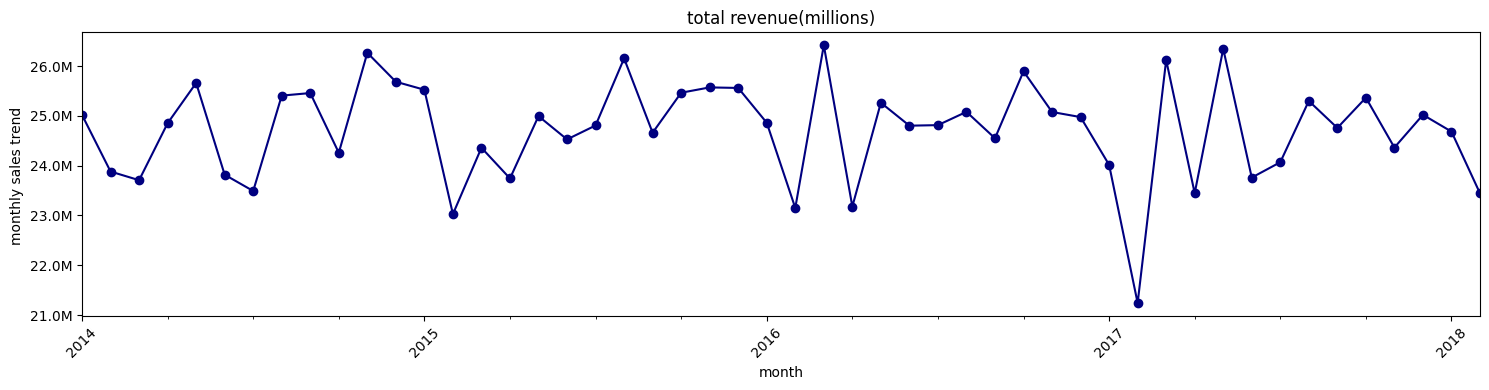

In [36]:
df['order_month']=df['order_date'].dt.to_period('M')
monthly_sales=df.groupby('order_month')['revenue'].sum()

plt.figure(figsize=(15,4))

monthly_sales.plot(marker='o',color='navy')

from matplotlib.ticker import FuncFormatter

formatter=FuncFormatter(lambda x,pos: f'{x/1e6:.1f}M')

plt.gca().yaxis.set_major_formatter(formatter)

plt.xlabel('month')
plt.ylabel('monthly sales trend ')
plt.title('total revenue(millions)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


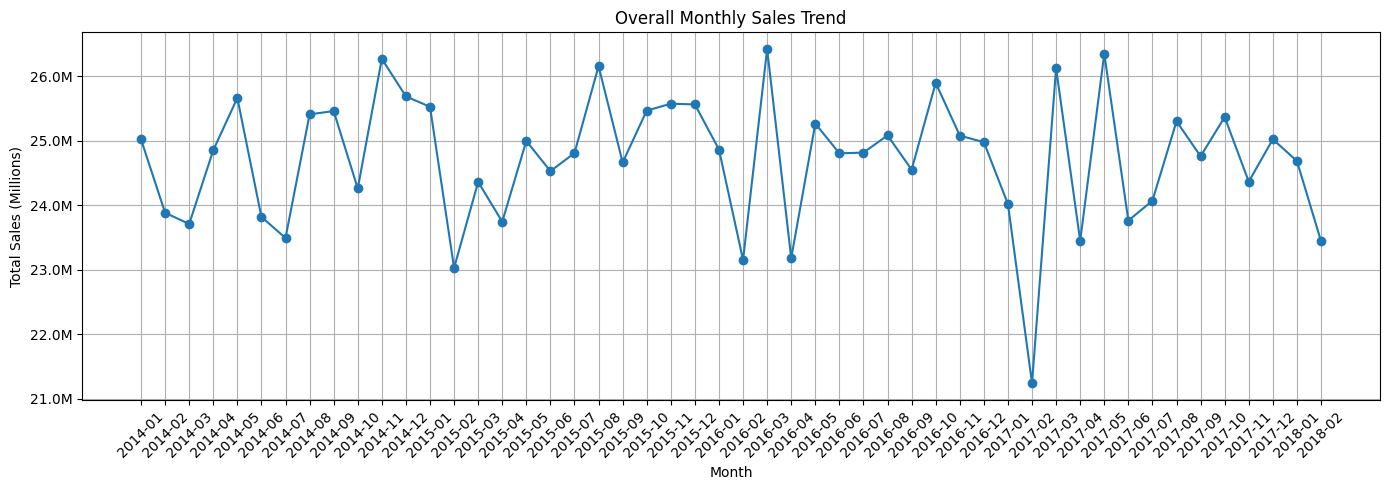

In [37]:


# 1. Ensure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. Create order_month column
df['order_month'] = df['order_date'].dt.to_period('M')

# 3. Calculate overall monthly sales (total revenue)
monthly_sales = (
    df.groupby('order_month')['revenue']
      .sum()
      .reset_index()
      .sort_values('order_month')
)

# 4. Plot monthly sales trend
plt.figure(figsize=(14,5))

plt.plot(
    monthly_sales['order_month'].astype(str),
    monthly_sales['revenue'],
    marker='o'
)

# 5. Format Y-axis in millions
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

# 6. Add labels and title
plt.xlabel('Month')
plt.ylabel('Total Sales (Millions)')
plt.title('Overall Monthly Sales Trend')

# 7. Improve readability
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
# 8. Show plot
plt.show()


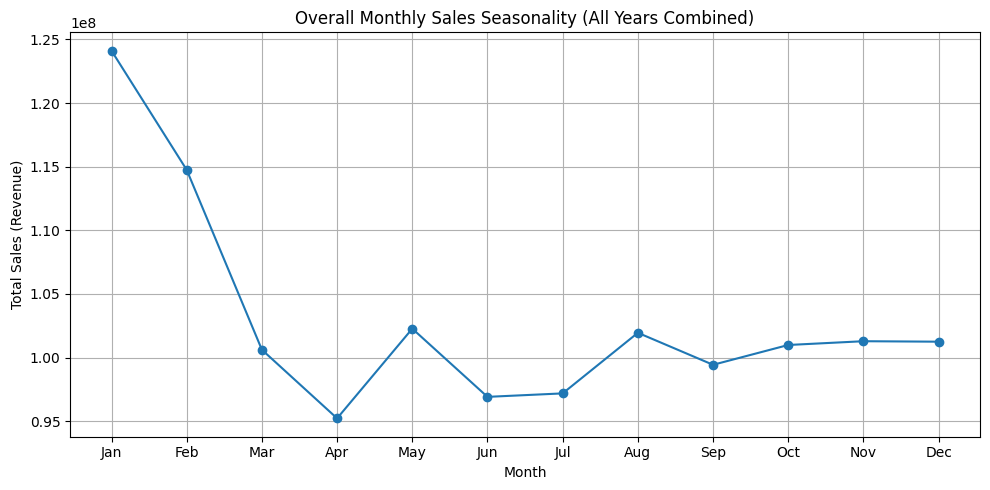

In [38]:


# 1. Ensure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. Extract calendar month number and month name
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.strftime('%b')  # Jan, Feb, etc.

# 3. Aggregate sales across ALL years by month
monthly_seasonality = (
    df.groupby(['month', 'month_name'])['revenue']
      .sum()
      .reset_index()
      .sort_values('month')
)

# 4. Plot overall monthly sales trend (seasonality)
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_seasonality['month_name'],
    monthly_seasonality['revenue'],
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Total Sales (Revenue)')
plt.title('Overall Monthly Sales Seasonality (All Years Combined)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [39]:
df.to_csv('final.csv')

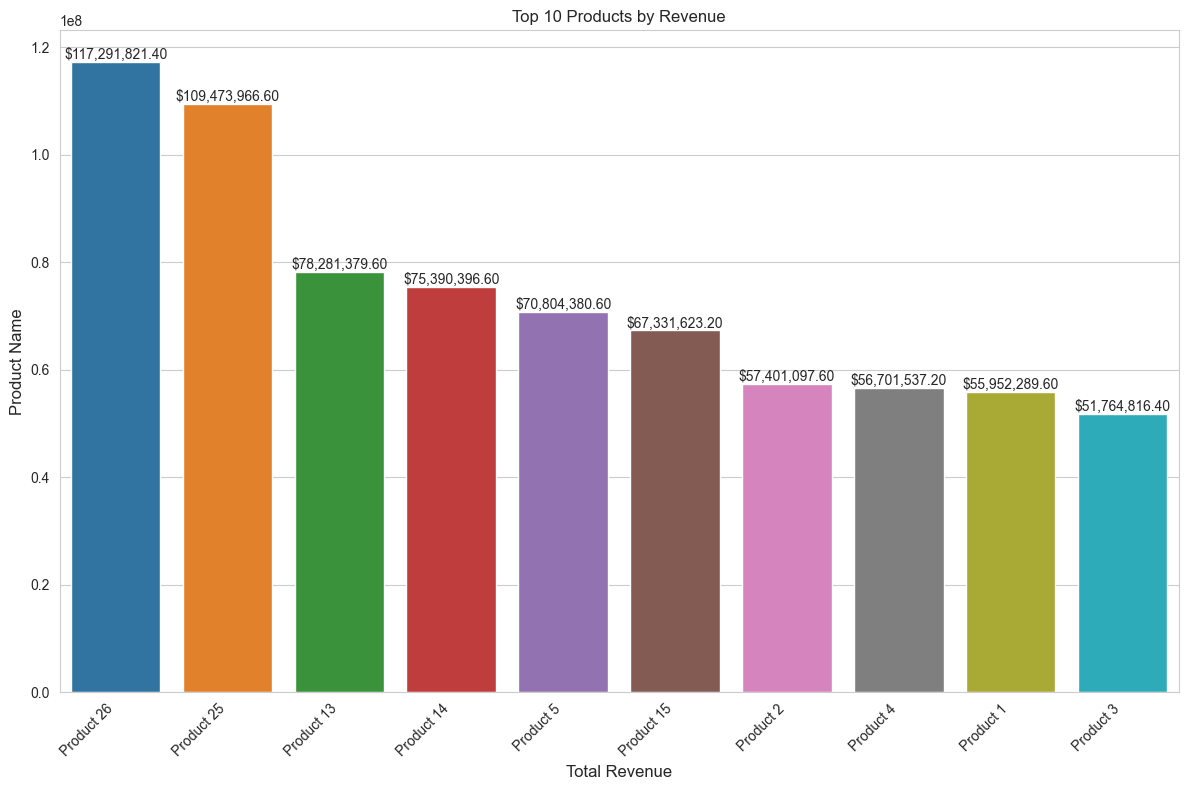

In [40]:

# Aggregate revenue by product
top_products = (
    df.groupby('product_name')['revenue']
      .sum()
      .reset_index()
      .sort_values('revenue', ascending=False)
      .head(10)
)

# Style
sns.set_style("whitegrid")

# Plot barplot
plt.figure(figsize=(12, 8))
ax=sns.barplot(
    data=top_products,
    x='product_name',
    y='revenue',    hue='product_name',palette='tab10'
)
# Add labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='${:,.2f}', padding=0)
    
plt.xlabel('Total Revenue',fontsize=12)
plt.ylabel('Product Name',fontsize=12)
plt.title('Top 10 Products by Revenue')
plt.xticks(rotation=45,ha='right')
plt.grid(True,axis='y')
plt.tight_layout()
plt.show()


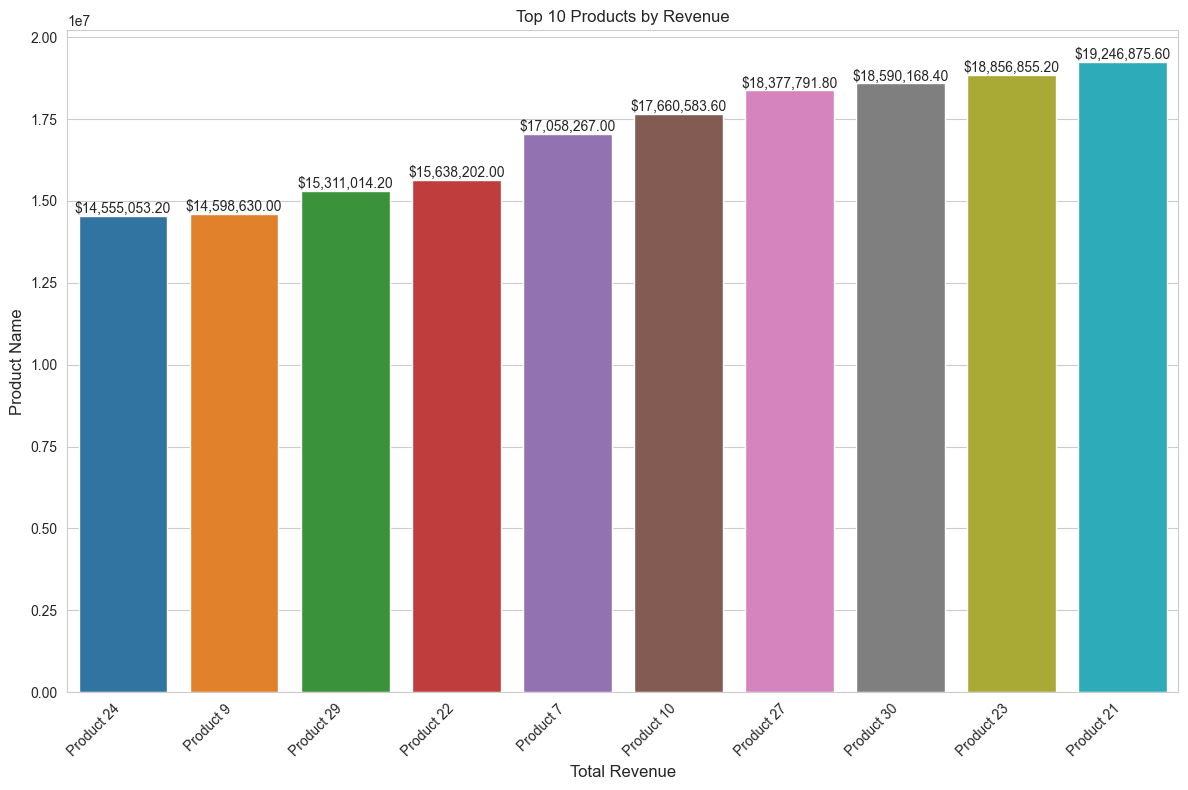

In [41]:

# Aggregate revenue by product
top_products = (
    df.groupby('product_name')['revenue']
      .sum()
      .reset_index()
      .sort_values('revenue', ascending=True)
      .head(10)
)

# Style
sns.set_style("whitegrid")

# Plot barplot
plt.figure(figsize=(12, 8))
ax=sns.barplot(
    data=top_products,
    x='product_name',
    y='revenue',    hue='product_name',palette='tab10'
)
# Add labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='${:,.2f}', padding=0)
    
plt.xlabel('Total Revenue',fontsize=12)
plt.ylabel('Product Name',fontsize=12)
plt.title('Top 10 Products by Revenue')
plt.xticks(rotation=45,ha='right')
plt.grid(True,axis='y')
plt.tight_layout()
plt.show()


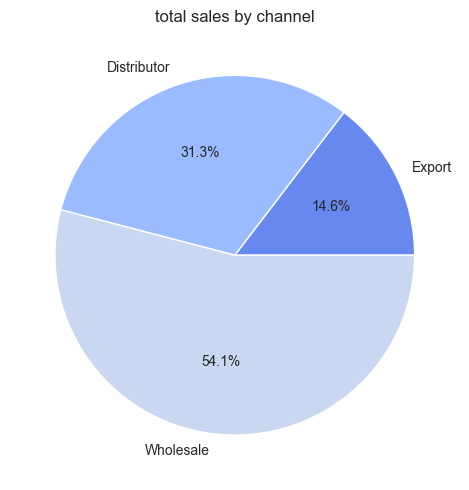

In [42]:
## sales by channel
chann_sales=df.groupby('channel')['revenue'].sum().sort_values(ascending=True)
plt.figure(figsize=(5,5))

plt.pie(chann_sales.values,
       labels=chann_sales.index,
        autopct='%1.1f%%',
       colors=sns.color_palette('coolwarm'))

plt.title('total sales by channel')
plt.tight_layout()
plt.show()

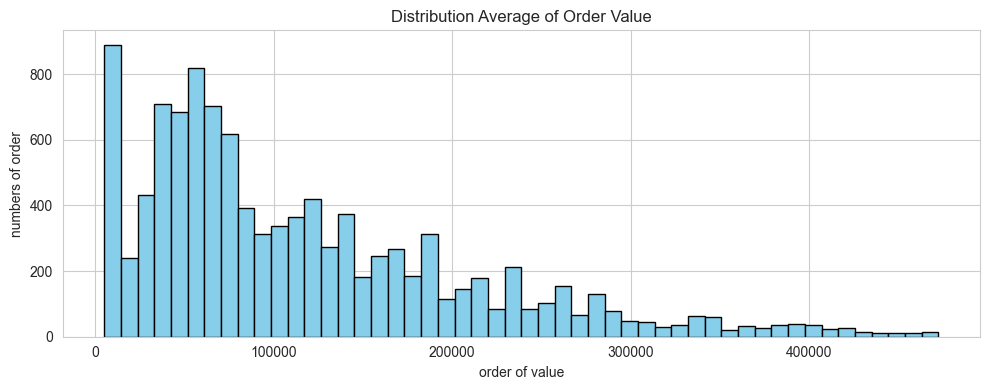

In [43]:
## average of order value(Aov) distribution
average_ov=df.groupby('order_number')['revenue'].sum()

plt.figure(figsize=(10,4))
plt.hist(average_ov,
        bins=50,
        color='skyblue',
        edgecolor='black')
plt.title("Distribution Average of Order Value")
plt.xlabel('order of value')
plt.ylabel('numbers of order')
plt.tight_layout()
plt.show()

In [44]:
df.head(5)

,order_number,order_date,channel,product_name,order_quantity,unit_price,revenue,total_unit,customer_name,county,...,latitude,longitude,region,budget,total_cost,profit,margine_profit,order_month,month,month_name
0,SO - 000225,2014-01-01,Wholesale,Product 27,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Chatham County,...,32.08354,-81.09983,South,NaN,10946.058,4048.542,27.0,2014-01,1,Jan
1,SO - 0003378,2014-01-01,Distributor,Product 20,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Johnson County,...,39.61366,-86.10665,Midwest,NaN,13969.098,11899.602,46.0,2014-01,1,Jan
2,SO - 0005126,2014-01-01,Wholesale,Product 26,6,978.2,5869.2,684.740,Amerisourc Corp,Alameda County,...,37.66243,-121.87468,West,NaN,4108.440,1760.760,30.0,2014-01,1,Jan
3,SO - 0005614,2014-01-01,Export,Product 7,7,2338.3,16368.1,1028.852,Colgate-Pa Group,Monroe County,...,39.16533,-86.52639,Midwest,NaN,7201.964,9166.136,56.0,2014-01,1,Jan
4,SO - 0005781,2014-01-01,Wholesale,Product 8,8,2291.4,18331.2,1260.270,Deseret Group,Hartford County,...,41.77524,-72.52443,Northeast,NaN,10082.160,8249.040,45.0,2014-01,1,Jan


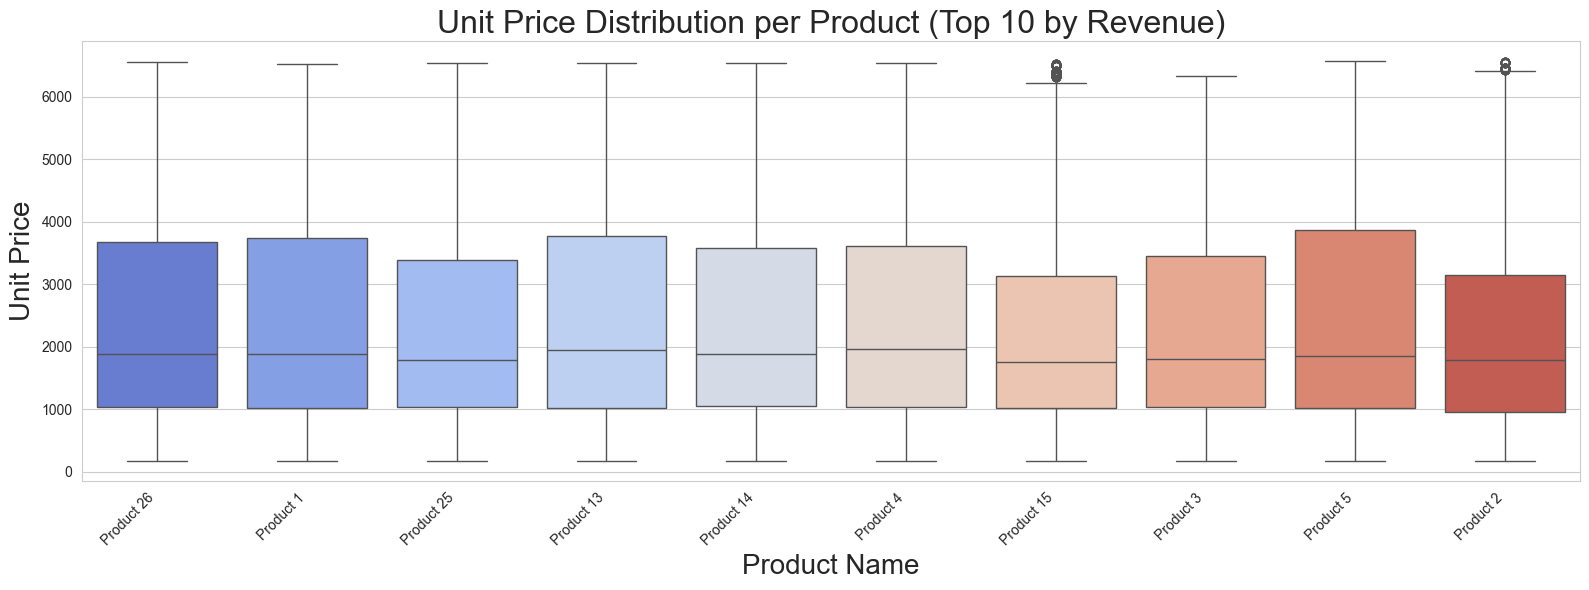

In [45]:
#unit price distribution per products
#top 10 states by revenue and order counts
#average profit margine by channel
#top and bottom 10 customers by revenue
#customers segmentation:revenue vs profit margine
#correlation heatmap
# (Optional) limit to top products to keep chart readable
top_products_names = (
    df.groupby('product_name')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .index
)

plt.figure(figsize=(16, 6))

sns.boxplot(
    data=df[df['product_name'].isin(top_products_names)],
    x='product_name',
    y='unit_price',
    hue='product_name',
    palette='coolwarm'
)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Product Name',fontsize=20)
plt.ylabel('Unit Price',fontsize=20)
plt.title('Unit Price Distribution per Product (Top 10 by Revenue)',fontsize=23)
plt.tight_layout()

plt.show()


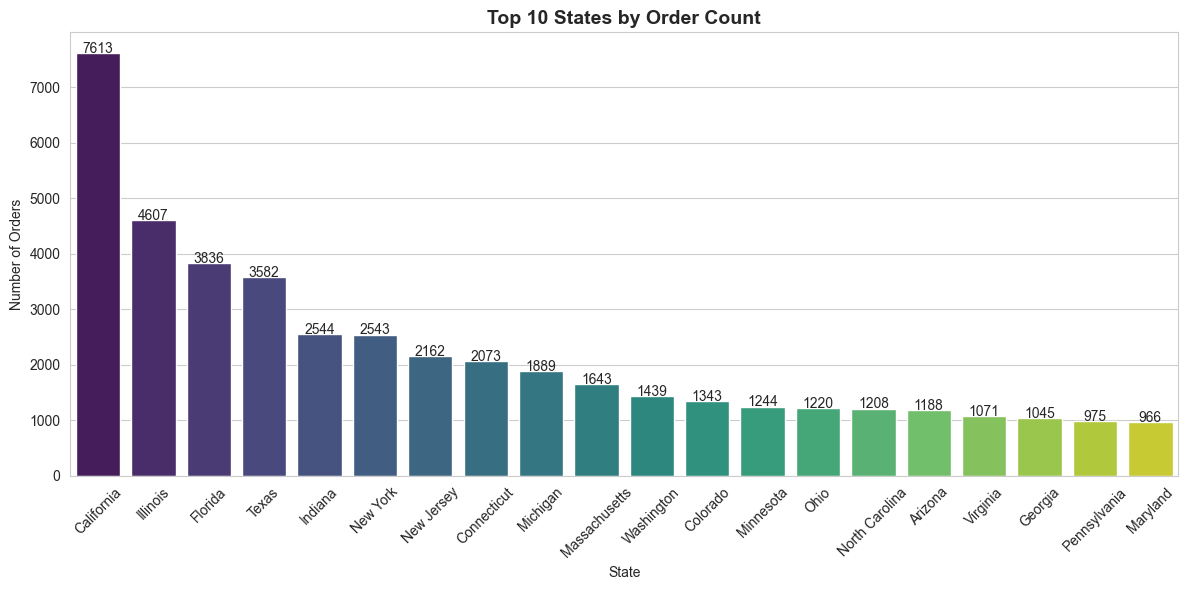

In [46]:


# Data
top_states_orders = (
    df.groupby('state')['order_number']
    .nunique()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name='order_count')
)

sns.set_style("whitegrid")
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_states_orders,
    x='state',          # categorical on X
    y='order_count',    # numeric on Y
    palette='viridis',
    hue='state'
)

plt.title('Top 10 States by Order Count', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

# Add value labels
for i, v in enumerate(top_states_orders['order_count']):
    ax.text(i, v + 1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()


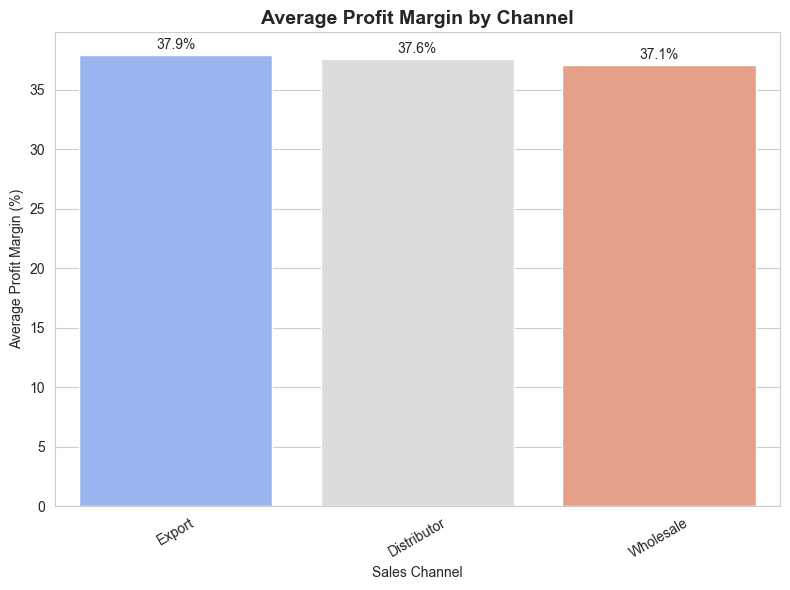

In [47]:



# Calculate average profit margin by channel
avg_margin_channel = (
    df.groupby('channel')['margine_profit']
    .mean()
    .reset_index()
    .sort_values(by='margine_profit', ascending=False)
)

# Seaborn style
sns.set_style("whitegrid")
plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=avg_margin_channel,
    x='channel',
    y='margine_profit',
    palette='coolwarm',
    hue='channel'
)

# Titles & labels
plt.title('Average Profit Margin by Channel', fontsize=14, fontweight='bold')
plt.xlabel('Sales Channel')
plt.ylabel('Average Profit Margin (%)')
plt.xticks(rotation=30)

# Add value labels
for i, v in enumerate(avg_margin_channel['margine_profit']):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

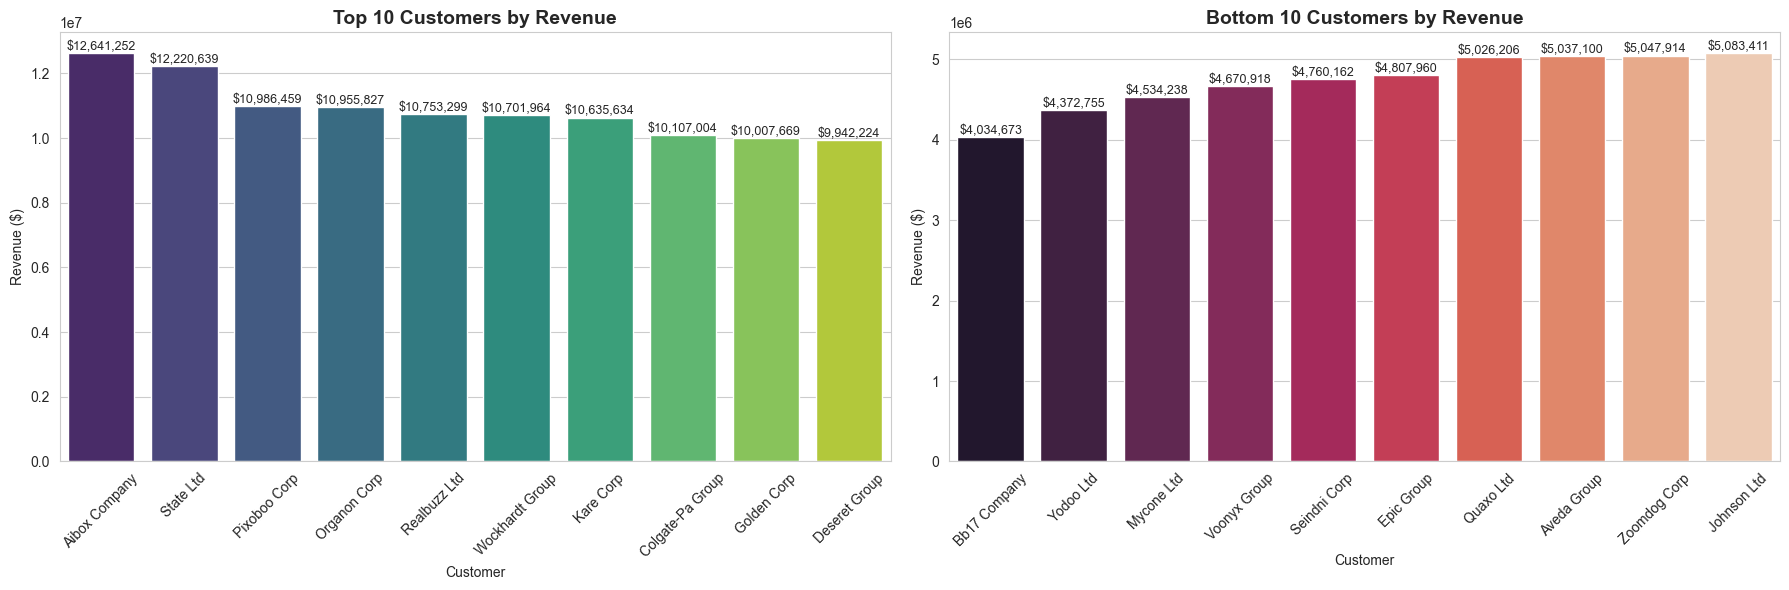

In [48]:

# Clean customer names (optional but recommended)
df['customer_name'] = df['customer_name'].str.strip().str.title()

# Aggregate revenue by customer
customer_revenue = (
    df.groupby('customer_name')['revenue']
    .sum()
    .reset_index()
)

# Top 10 and Bottom 10
top_customers = customer_revenue.sort_values('revenue', ascending=False).head(10)
bottom_customers = customer_revenue.sort_values('revenue', ascending=True).head(10)

# Seaborn style
sns.set_style("whitegrid")

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# ---- Top 10 Plot ----
ax1 = sns.barplot(
    data=top_customers,
    x='customer_name',
    y='revenue',
    palette='viridis',
    hue='customer_name',
    ax=axes[0]
)
ax1.set_title('Top 10 Customers by Revenue', fontsize=14, fontweight='bold')
ax1.set_xlabel('Customer')
ax1.set_ylabel('Revenue ($)')
ax1.tick_params(axis='x', rotation=45)

for i, v in enumerate(top_customers['revenue']):
    ax1.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=9)

# ---- Bottom 10 Plot ----
ax2 = sns.barplot(
    data=bottom_customers,
    x='customer_name',
    y='revenue',
    palette='rocket',
    hue='customer_name',
    ax=axes[1]
)
ax2.set_title('Bottom 10 Customers by Revenue', fontsize=14, fontweight='bold')
ax2.set_xlabel('Customer')
ax2.set_ylabel('Revenue ($)')
ax2.tick_params(axis='x', rotation=45)

for i, v in enumerate(bottom_customers['revenue']):
    ax2.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [49]:
df.columns

Index(['order_number', 'order_date', 'channel', 'product_name',
       'order_quantity', 'unit_price', 'revenue', 'total_unit',
       'customer_name', 'county', 'state_code', 'state', 'latitude',
       'longitude', 'region', 'budget', 'total_cost', 'profit',
       'margine_profit', 'order_month', 'month', 'month_name'],
      dtype='object')

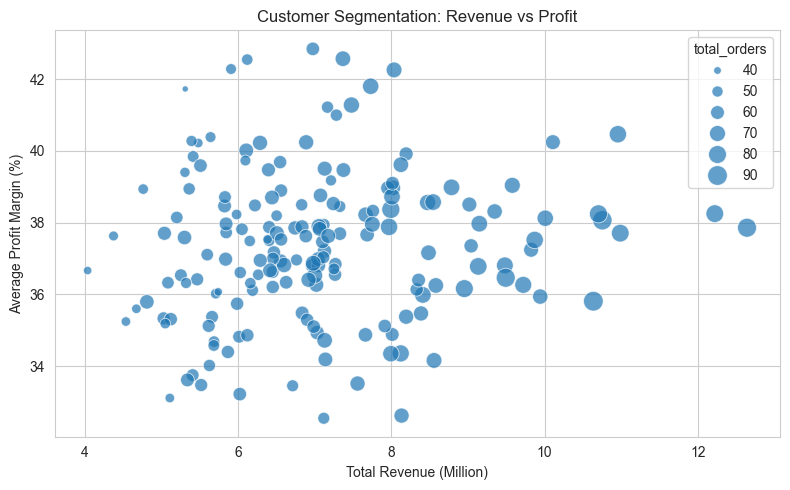

In [50]:

# Step 1: Aggregate data per customer
cust_summary = df.groupby('customer_name').agg(
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum'),
    avg_margin=('margine_profit', 'mean'),
    total_orders=('order_number', 'nunique')
).reset_index()

# Step 2: Convert revenue to millions
cust_summary['total_revenue_m'] = cust_summary['total_revenue'] / 1e6

# Step 3: Plot graph (Bubble Chart)
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=cust_summary,
    x='total_revenue_m',
    y='avg_margin',
    size='total_orders',
    sizes=(20, 200),
    alpha=0.7
)

plt.title("Customer Segmentation: Revenue vs Profit")
plt.xlabel("Total Revenue (Million)")
plt.ylabel("Average Profit Margin (%)")

plt.tight_layout()
plt.show()

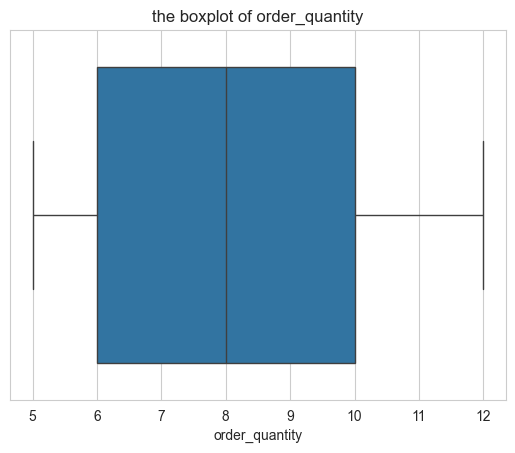

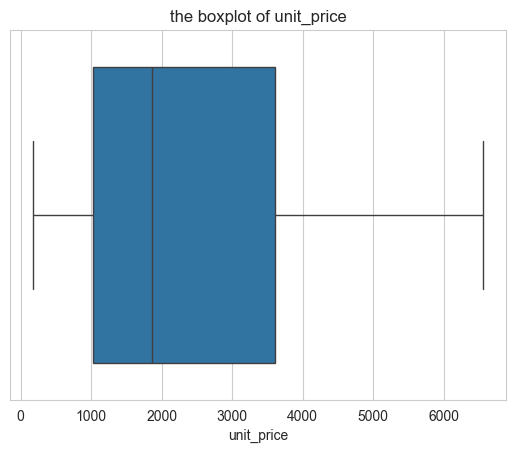

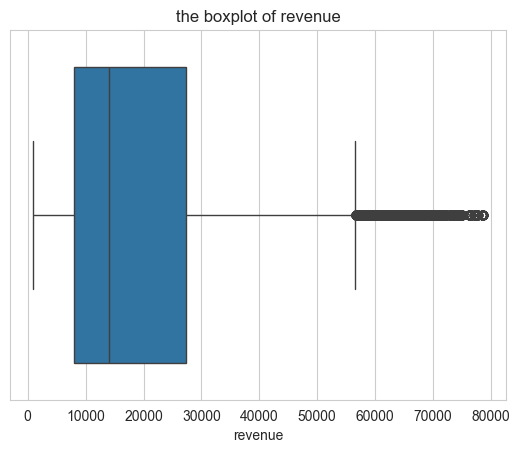

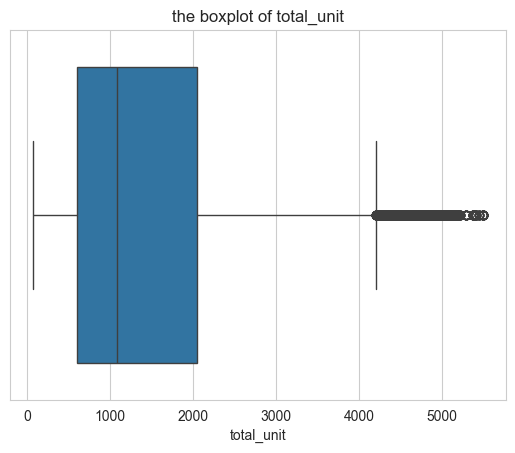

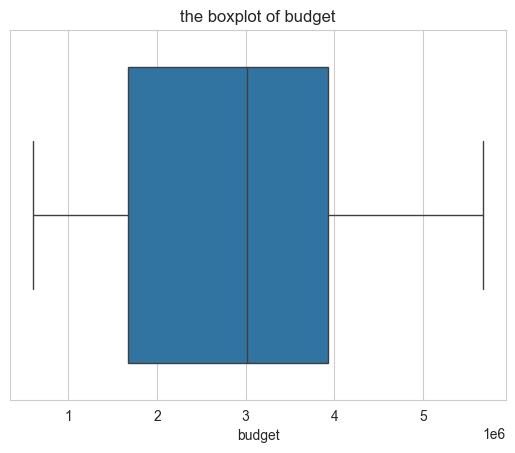

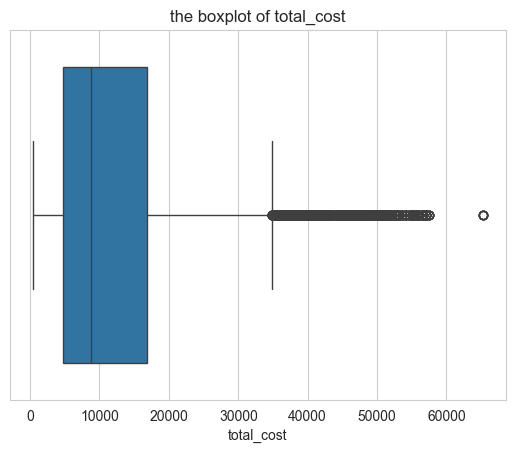

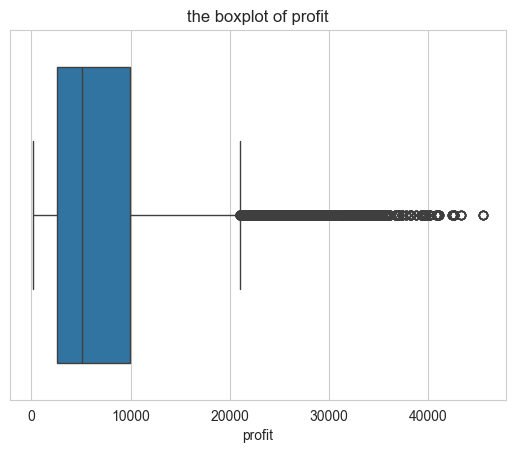

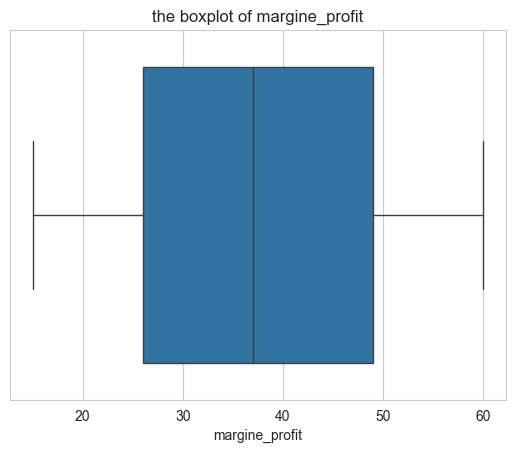

In [51]:
num_col=[
       'order_quantity', 'unit_price', 'revenue', 'total_unit', 'budget', 'total_cost', 'profit',
       'margine_profit', ]
for col in num_col:

 sns.boxplot(x=col,data=df)
 plt.title(f'the boxplot of {col}')
 plt.show()

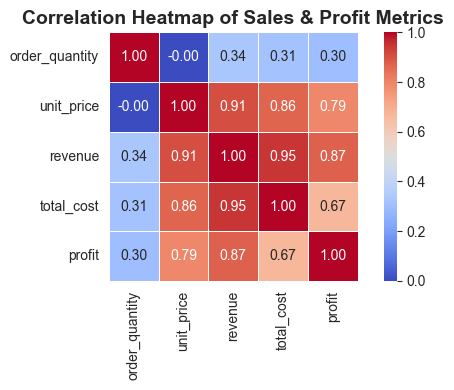

In [53]:

# Select only numeric columns
corr_data = df[[
    'order_quantity',
    'unit_price',
    'revenue',
    
    
    'total_cost',
    'profit'
    
]]

# Calculate correlation matrix
corr_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(
    corr_matrix,
    annot=True,          # show values
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)

plt.title('Correlation Heatmap of Sales & Profit Metrics',
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
df.columns